# CITS4012 自然语言处理个人作业

## 生物医学摘要分类

**学号：** 请填写学号  
**提交时间：** 2026 年 9 月

本 Notebook 在受控的 PyTorch LSTM 分类器中研究自训练词向量与预训练生物医学词向量，使用 UMNSRS 对词表示进行内在评估，引入显式的生物医学命名实体识别（NER）特征，并最终提供一个自包含的 Google Colab 推理表单。

### 实验方案

将官方训练集一次性按类别分层划分为 80% 的拟合分区和 20% 的验证分区。所有词表示与分类器配置均在不查看测试标签的前提下确定。只有在模型配置锁定后，才使用官方测试集。除明确指定的被比较因素外，每组比较均使用相同的数据划分、词表、截断策略、网络架构、优化器、类别权重与随机种子。

## 环境配置

In [1]:
import importlib.util
import subprocess
import sys

required = {
    "gdown": "gdown",
    "gensim": "gensim>=4.4.0",
    "pandas": "pandas",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "spacy": "spacy==3.7.5",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn"
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

models = {
    "en_core_sci_md": "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz",
    "en_ner_bc5cdr_md": "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz"
}
for module, source in models.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", source])

print("环境准备完成")

环境准备完成


In [2]:
import base64
import copy
import gzip
import io
import json
import math
import random
import re
import warnings
from collections import Counter
from pathlib import Path

import gdown
import gensim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from gensim.models import Word2Vec
from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 4012
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch {torch.__version__}；运行设备={device}")

PyTorch 2.14.0；运行设备=mps


### 数据获取与完整性检查

以下代码使用作业说明共享文件夹中四个官方数据文件的固定 Google Drive 文件 ID 下载数据。这些文件仅作为运行时输入，不属于需要提交的 Notebook 内容。

In [3]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
file_ids = {
    "medical_tc_labels.csv": "1gJxXt_H7eGh-XbB5pS0L7jmcz4HbTGkx",
    "medical_tc_test.csv": "18Nxoxgr5xqqtDiDwSIBl-l_4JG-Uam3o",
    "medical_tc_train.csv": "1rJlKpdDuDjF03ZytOQxLGMSx5OVh2wtR",
    "umnsrs_similarity_mod.csv": "1DZxOayRveumzBTIS3sB0VQXmfSx9EC6t"
}
for filename, file_id in file_ids.items():
    destination = DATA_DIR / filename
    if not destination.exists():
        gdown.download(id=file_id, output=str(destination), quiet=False)

labels_df = pd.read_csv(DATA_DIR / "medical_tc_labels.csv")
train_df = pd.read_csv(DATA_DIR / "medical_tc_train.csv")
test_df = pd.read_csv(DATA_DIR / "medical_tc_test.csv")
umnsrs_df = pd.read_csv(DATA_DIR / "umnsrs_similarity_mod.csv")

assert list(train_df.columns) == ["condition_label", "medical_abstract"]
assert list(test_df.columns) == ["condition_label", "medical_abstract"]
assert train_df.isna().sum().sum() == 0 and test_df.isna().sum().sum() == 0
assert set(train_df.condition_label) == set(labels_df.condition_label)
assert set(test_df.condition_label) == set(labels_df.condition_label)

display(pd.DataFrame({
    "dataset": ["training", "test", "UMNSRS"],
    "rows": [len(train_df), len(test_df), len(umnsrs_df)],
    "columns": [train_df.shape[1], test_df.shape[1], umnsrs_df.shape[1]]
}))
display(labels_df)

,dataset,rows,columns
0,training,11550,2
1,test,2883,2
2,UMNSRS,449,5


,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions


In [4]:
fit_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["condition_label"]
)
fit_df = train_df.iloc[fit_idx].reset_index(drop=True)
val_df = train_df.iloc[val_idx].reset_index(drop=True)
split_distribution = pd.concat({
    "fit": fit_df.condition_label.value_counts(normalize=True).sort_index(),
    "validation": val_df.condition_label.value_counts(normalize=True).sort_index(),
    "test": test_df.condition_label.value_counts(normalize=True).sort_index()
}, axis=1)
split_distribution.index = split_distribution.index.map(dict(zip(labels_df.condition_label, labels_df.condition_name)))
display(split_distribution.round(3))
print(f"拟合分区={len(fit_df):,}；验证分区={len(val_df):,}；未参与调参的测试集={len(test_df):,}")

,fit,validation,test
condition_label,,,
neoplasms,0.219,0.219,0.219
digestive system diseases,0.103,0.103,0.104
nervous system diseases,0.133,0.133,0.134
cardiovascular diseases,0.211,0.211,0.211
general pathological conditions,0.333,0.333,0.333


拟合分区=9,240；验证分区=2,310；未参与调参的测试集=2,883


## Task 1 - 训练自有词向量

### 文本预处理

词向量语料仅包含官方训练集中的拟合分区。文本统一转换为小写，并通过确定性的正则表达式进行分词；该表达式保留字母词、词内连字符或撇号，以及数值测量值，同时删除独立标点。保留停用词，因为它们能为 Word2Vec 提供局部句法上下文。不进行词干提取，因为生物医学词语的屈折形式和具体词形可能携带语义信息。

### 受控词向量实验

训练三组 200 维 Word2Vec 候选模型。向量维度、最小词频、负采样数量、训练轮数和随机种子保持不变，仅改变训练架构与上下文窗口。CBOW 作为针对高频词的高效基线；Skip-gram 预期更适合表示较少出现的生物医学术语；更大的上下文窗口用于检验概念级语义相似度是否受益于更广的上下文。Task 3 使用 UMNSRS 比较这些候选模型，整个过程不使用分类测试标签。

In [5]:
TOKEN_PATTERN = re.compile(r"[a-z]+(?:[-'][a-z]+)?|\d+(?:\.\d+)?")

def tokenize(text):
    return TOKEN_PATTERN.findall(str(text).lower())

fit_tokens = [tokenize(text) for text in fit_df.medical_abstract]
val_tokens = [tokenize(text) for text in val_df.medical_abstract]
test_tokens = [tokenize(text) for text in test_df.medical_abstract]
lengths = np.array([len(tokens) for tokens in fit_tokens])
display(pd.Series(lengths).describe(percentiles=[0.50, 0.90, 0.95, 0.99]).to_frame("tokens per abstract").round(1))
print("示例词元：", fit_tokens[0][:30])

,tokens per abstract
count,9240.0
mean,181.8
std,77.8
min,25.0
50%,177.0
90%,278.0
95%,309.0
99%,386.0
max,606.0


示例词元： ['premalignant', 'lesions', 'role', 'of', 'antioxidant', 'vitamins', 'and', 'beta-carotene', 'in', 'risk', 'reduction', 'and', 'prevention', 'of', 'malignant', 'transformation', 'epidemiological', 'studies', 'have', 'shown', 'that', 'diets', 'rich', 'in', 'one', 'or', 'more', 'antioxidant', 'nutrients', 'may']


In [6]:
embedding_specs = {
    "CBOW-w5": {"sg": 0, "window": 5},
    "SG-w5": {"sg": 1, "window": 5},
    "SG-w10": {"sg": 1, "window": 10}
}
self_embeddings = {}
embedding_rows = []
for name, spec in embedding_specs.items():
    model = Word2Vec(
        sentences=fit_tokens,
        vector_size=200,
        window=spec["window"],
        min_count=2,
        sg=spec["sg"],
        negative=10,
        sample=1e-4,
        workers=1,
        seed=SEED,
        epochs=8
    )
    self_embeddings[name] = model
    embedding_rows.append({
        "candidate": name,
        "architecture": "skip-gram" if spec["sg"] else "CBOW",
        "window": spec["window"],
        "dimensions": model.vector_size,
        "vocabulary": len(model.wv)
    })
display(pd.DataFrame(embedding_rows))
for name, model in self_embeddings.items():
    neighbours = [word for word, score in model.wv.most_similar("disease", topn=5)]
    print(f"{name}: disease -> {', '.join(neighbours)}")

,candidate,architecture,window,dimensions,vocabulary
0,CBOW-w5,CBOW,5,200,27268
1,SG-w5,skip-gram,5,200,27268
2,SG-w10,skip-gram,10,200,27268


CBOW-w5: disease -> end-stage, crohn's, kawasaki, cerebrovascular, alzheimer's
SG-w5: disease -> extraintestinal, acne, angiographically-proven, plethora, editorial
SG-w10: disease -> ganglioneuromatosis, satisfying, copenhagen, polyostotic, angiographically-proven


候选模型使用最小词频 2，以删除仅出现一次的噪声，同时保留低频临床术语。对于该语料规模，每个正样本使用 10 个负样本是合理的计算折中。单工作线程与固定随机种子提升实验可复现性。训练 8 轮可让模型重复观察语料，同时避免 Notebook 运行时间过长。

## Task 2 - 预训练生物医学词向量

预训练表示选用 AllenAI **scispaCy `en_core_sci_md` 0.5.4** 模型中的 200 维静态词向量表。该词向量表包含 50,000 行向量，并针对科学与生物医学语言开发，因此在医学摘要中的疾病名称、化学物质、医疗操作和解剖学术语上，比通用新闻语料词向量更合适。

资料来源：

- [scispaCy 模型与发布文件](https://allenai.github.io/scispacy/)
- [Neumann 等（2019），ScispaCy: Fast and Robust Models for Biomedical Natural Language Processing](https://aclanthology.org/W19-5034/)

本任务只需要模型的词表与静态向量表，因此禁用句法分析和 NER 等管线组件。后续 NER 任务会使用另一套专门训练的模型。

In [7]:
pretrained_nlp = spacy.load(
    "en_core_sci_md",
    disable=["tok2vec", "tagger", "parser", "ner", "lemmatizer", "attribute_ruler"]
)
print("模型：", pretrained_nlp.meta["name"], pretrained_nlp.meta["version"])
print("静态词向量表：", pretrained_nlp.vocab.vectors.shape)
for term in ["neoplasm", "cardiovascular", "heparin", "gastrointestinal"]:
    lexeme = pretrained_nlp.vocab[term]
    print(term, "存在向量=", lexeme.has_vector, "维度=", len(lexeme.vector))

模型： core_sci_md 0.5.4
静态词向量表： (50000, 200)
neoplasm 存在向量= True 维度= 200
cardiovascular 存在向量= True 维度= 200
heparin 存在向量= True 维度= 200
gastrointestinal 存在向量= True 维度= 200


## Task 3 - 使用 UMNSRS 进行内在评估

每个概念均使用与训练阶段相同的预处理函数进行分词。多词概念以其中所有可用词元向量的算术平均表示。仅当某个概念的所有词元都没有向量时，才将该概念视为词表外（OOV）。当一对概念都可获得向量时，该概念对才可以评分。随后计算余弦相似度，并使用 Spearman 等级相关系数与人工相似度评分进行比较。

由于覆盖率差异可能干扰模型比较，本实验报告两类结果：每个模型在其所有可评分概念对上的表现，以及两个模型在完全相同的可评分交集上的表现。共同概念对上的相关系数是主要的公平比较指标。内在评估不会为 OOV 概念人为构造向量。

In [8]:
def mean_concept_vector(concept, lookup):
    vectors = [lookup(token) for token in tokenize(concept)]
    vectors = [vector for vector in vectors if vector is not None]
    if not vectors:
        return None
    return np.mean(vectors, axis=0)

def cosine_similarity(left, right):
    denominator = np.linalg.norm(left) * np.linalg.norm(right)
    return float(np.dot(left, right) / denominator) if denominator else np.nan

def evaluate_embedding(frame, lookup):
    similarities = []
    valid = []
    for row in frame.itertuples():
        left = mean_concept_vector(row.text_1, lookup)
        right = mean_concept_vector(row.text_2, lookup)
        is_valid = left is not None and right is not None
        valid.append(is_valid)
        similarities.append(cosine_similarity(left, right) if is_valid else np.nan)
    valid = np.array(valid)
    similarities = np.array(similarities)
    coefficient, p_value = spearmanr(frame.loc[valid, "label"], similarities[valid])
    return {"valid": valid, "similarities": similarities, "rho": coefficient, "p": p_value}

intrinsic = {}
for name, model in self_embeddings.items():
    intrinsic[name] = evaluate_embedding(
        umnsrs_df,
        lambda token, keyed=model.wv: keyed[token] if token in keyed else None
    )
intrinsic["scispaCy-md"] = evaluate_embedding(
    umnsrs_df,
    lambda token: pretrained_nlp.vocab[token].vector if pretrained_nlp.vocab[token].has_vector else None
)

intrinsic_rows = []
for name, result in intrinsic.items():
    intrinsic_rows.append({
        "embedding": name,
        "scored_pairs": int(result["valid"].sum()),
        "coverage": result["valid"].mean(),
        "Spearman_rho_all_scorable": result["rho"],
        "p_value": result["p"]
    })
display(pd.DataFrame(intrinsic_rows).round(4))

,embedding,scored_pairs,coverage,Spearman_rho_all_scorable,p_value
0,CBOW-w5,229,0.5100,0.2356,0.0003
1,SG-w5,229,0.5100,0.3787,0.0000
2,SG-w10,229,0.5100,0.4740,0.0000
3,scispaCy-md,432,0.9621,0.4957,0.0000


In [9]:
self_names = list(embedding_specs)
common_rows = []
for name in self_names:
    common = intrinsic[name]["valid"] & intrinsic["scispaCy-md"]["valid"]
    self_rho = spearmanr(umnsrs_df.loc[common, "label"], intrinsic[name]["similarities"][common]).statistic
    pretrained_rho = spearmanr(umnsrs_df.loc[common, "label"], intrinsic["scispaCy-md"]["similarities"][common]).statistic
    common_rows.append({
        "self_candidate": name,
        "common_pairs": int(common.sum()),
        "self_rho": self_rho,
        "pretrained_rho": pretrained_rho
    })
common_results = pd.DataFrame(common_rows)
display(common_results.round(4))
best_self_name = common_results.sort_values("self_rho", ascending=False).iloc[0]["self_candidate"]
best_self_embedding = self_embeddings[best_self_name]
print("选定的自训练词向量：", best_self_name)

,self_candidate,common_pairs,self_rho,pretrained_rho
0,CBOW-w5,229,0.2356,0.5323
1,SG-w5,229,0.3787,0.5323
2,SG-w10,229,0.4740,0.5323


选定的自训练词向量： SG-w10


### 实验结果

窗口为 10 的 Skip-gram 是表现最好的自训练候选模型（ρ = 0.4740），优于窗口为 5 的 Skip-gram（0.3787）和 CBOW（0.2356）。更宽的上下文可能更适合生物医学概念相似度，因为这类语义关系往往依赖主题层面的上下文，而不仅是相邻句法信息。因此，后续分类实验选用 SG-w10。

自训练词表可评分 449 个概念对中的 229 个，覆盖率为 51.00%；scispaCy 可评分 432 个，覆盖率为 96.21%。在完全相同的 229 个概念对上，scispaCy 的 ρ 为 0.5323，而 SG-w10 为 0.4740，绝对优势为 0.0583。两组相关性均具有统计显著性（p < 0.001）。预训练向量的优势在控制覆盖率后仍然存在，同时更高的整体覆盖率也具有实际价值。剩余 OOV 情况主要来自组成词元缺失的概念；对可用组成词取平均虽然提高了覆盖率，但可能丢失短语特有语义。

## Task 4 - 医学摘要分类

### 表示方法与数据控制

词表仅根据拟合分区构建，并限制为最多 15,000 个词元。所有模型接收完全相同的词元索引。若摘要超过 192 个词元，则保留开头 96 个和结尾 96 个词元；该策略既保留研究目标，也保留通常位于摘要末尾的结论，同时保证受控实验可在 Colab 中实际运行。`<PAD>` 的索引为零且不参与学习，未见词元映射到 `<UNK>`。

词嵌入矩阵分别由选定的自训练模型或 scispaCy 初始化。某个来源中缺失的词元使用确定性的小幅随机向量初始化。两组嵌入均允许微调，以学习与目标类别相关的表示。采用带类别权重的交叉熵，以缓解中等程度的类别不平衡。

### 网络架构实验

本实验选择 LSTM 作为要求中的序列架构。首先只使用自训练词向量，通过验证集 macro-F1 比较三种配置，从而将架构选择与“预训练/自训练词向量”的比较分离。候选配置用于检验方向性与模型容量；优化器、学习率、词表和预处理均保持一致。

In [10]:
MAX_VOCAB = 15000
MAX_LEN = 192
token_counts = Counter(token for document in fit_tokens for token in document)
vocabulary_tokens = [token for token, count in token_counts.most_common() if count >= 2][:MAX_VOCAB - 2]
token_to_idx = {"<PAD>": 0, "<UNK>": 1, **{token: index + 2 for index, token in enumerate(vocabulary_tokens)}}

def truncate_tokens(tokens):
    if len(tokens) <= MAX_LEN:
        return tokens
    half = MAX_LEN // 2
    return tokens[:half] + tokens[-half:]

def encode_tokens(tokens):
    selected = truncate_tokens(tokens)
    return [token_to_idx.get(token, 1) for token in selected]

fit_sequences = [encode_tokens(tokens) for tokens in fit_tokens]
val_sequences = [encode_tokens(tokens) for tokens in val_tokens]
test_sequences = [encode_tokens(tokens) for tokens in test_tokens]
label_to_index = {label: index for index, label in enumerate(sorted(labels_df.condition_label))}
index_to_name = dict(enumerate(labels_df.sort_values("condition_label").condition_name.tolist()))
y_fit = fit_df.condition_label.map(label_to_index).to_numpy()
y_val = val_df.condition_label.map(label_to_index).to_numpy()
y_test = test_df.condition_label.map(label_to_index).to_numpy()
print(f"词表大小={len(token_to_idx):,}；最大序列长度={MAX_LEN}")

词表大小=15,000；最大序列长度=192


In [11]:
def build_embedding_matrix(lookup, dimension=200):
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(0, 0.05, size=(len(token_to_idx), dimension)).astype(np.float32)
    matrix[0] = 0
    found = 0
    for token, index in token_to_idx.items():
        if index < 2:
            continue
        vector = lookup(token)
        if vector is not None:
            matrix[index] = vector
            found += 1
    return matrix, found / (len(token_to_idx) - 2)

self_matrix, self_coverage = build_embedding_matrix(
    lambda token: best_self_embedding.wv[token] if token in best_self_embedding.wv else None
)
pretrained_matrix, pretrained_coverage = build_embedding_matrix(
    lambda token: pretrained_nlp.vocab[token].vector if pretrained_nlp.vocab[token].has_vector else None
)
display(pd.DataFrame({
    "embedding": [best_self_name, "scispaCy-md"],
    "classifier_vocabulary_coverage": [self_coverage, pretrained_coverage],
    "dimensions": [self_matrix.shape[1], pretrained_matrix.shape[1]]
}).round(4))

,embedding,classifier_vocabulary_coverage,dimensions
0,SG-w10,1.0000,200
1,scispaCy-md,0.9654,200


In [12]:
class AbstractDataset(Dataset):
    def __init__(self, sequences, labels, extra_features=None):
        self.sequences = sequences
        self.labels = labels
        self.extra_features = extra_features

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        features = np.zeros(0, dtype=np.float32) if self.extra_features is None else self.extra_features[index]
        return self.sequences[index], int(self.labels[index]), features

def collate_batch(batch):
    sequences, labels, features = zip(*batch)
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    padded = torch.zeros((len(sequences), int(lengths.max())), dtype=torch.long)
    for row, sequence in enumerate(sequences):
        padded[row, :len(sequence)] = torch.tensor(sequence, dtype=torch.long)
    return padded, lengths, torch.tensor(labels, dtype=torch.long), torch.tensor(np.stack(features), dtype=torch.float32)

class LSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, bidirectional, dropout, feature_dim=0):
        super().__init__()
        weights = torch.tensor(embedding_matrix, dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(weights, freeze=False, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=weights.shape[1],
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=bidirectional
        )
        representation_size = hidden_size * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.hidden = nn.Linear(representation_size + feature_dim, hidden_size)
        self.output = nn.Linear(hidden_size, len(index_to_name))
        self.bidirectional = bidirectional

    def forward(self, tokens, lengths, features=None):
        embedded = self.dropout(self.embedding(tokens))
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        representation = torch.cat((hidden[-2], hidden[-1]), dim=1) if self.bidirectional else hidden[-1]
        if features is not None and features.shape[1] > 0:
            representation = torch.cat((representation, features), dim=1)
        representation = self.dropout(torch.relu(self.hidden(representation)))
        return self.output(representation)

def make_loaders(train_features=None, validation_features=None, batch_size=128):
    generator = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(
        AbstractDataset(fit_sequences, y_fit, train_features),
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_batch,
        generator=generator
    )
    validation_loader = DataLoader(
        AbstractDataset(val_sequences, y_val, validation_features),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_batch
    )
    return train_loader, validation_loader

In [13]:
class_counts = np.bincount(y_fit, minlength=len(index_to_name))
class_weights = torch.tensor(len(y_fit) / (len(index_to_name) * class_counts), dtype=torch.float32, device=device)

def evaluate_model(model, loader):
    model.eval()
    losses = []
    predictions = []
    targets = []
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    with torch.no_grad():
        for tokens, lengths, labels, features in loader:
            tokens, labels, features = tokens.to(device), labels.to(device), features.to(device)
            logits = model(tokens, lengths, features)
            losses.append(criterion(logits, labels).item())
            predictions.extend(logits.argmax(1).cpu().numpy())
            targets.extend(labels.cpu().numpy())
    return {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(targets, predictions),
        "macro_f1": f1_score(targets, predictions, average="macro"),
        "weighted_f1": f1_score(targets, predictions, average="weighted"),
        "predictions": np.array(predictions),
        "targets": np.array(targets)
    }

def train_model(embedding_matrix, config, train_features=None, validation_features=None, max_epochs=5, patience=2):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    model = LSTMClassifier(
        embedding_matrix,
        hidden_size=config["hidden_size"],
        bidirectional=config["bidirectional"],
        dropout=config["dropout"],
        feature_dim=0 if train_features is None else train_features.shape[1]
    ).to(device)
    train_loader, validation_loader = make_loaders(train_features, validation_features)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimiser = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    best_state = None
    best_f1 = -1
    stale = 0
    history = []
    for epoch in range(1, max_epochs + 1):
        model.train()
        training_losses = []
        for tokens, lengths, labels, features in train_loader:
            tokens, labels, features = tokens.to(device), labels.to(device), features.to(device)
            optimiser.zero_grad(set_to_none=True)
            logits = model(tokens, lengths, features)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            training_losses.append(loss.item())
        validation = evaluate_model(model, validation_loader)
        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(training_losses)),
            "val_loss": validation["loss"],
            "val_macro_f1": validation["macro_f1"]
        })
        if validation["macro_f1"] > best_f1 + 1e-4:
            best_f1 = validation["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
        if stale >= patience:
            break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), evaluate_model(model, validation_loader)

In [14]:
architecture_configs = {
    "UniLSTM-64": {"hidden_size": 64, "bidirectional": False, "dropout": 0.30},
    "BiLSTM-64": {"hidden_size": 64, "bidirectional": True, "dropout": 0.30},
    "BiLSTM-96": {"hidden_size": 96, "bidirectional": True, "dropout": 0.40}
}
architecture_rows = []
architecture_histories = {}
for name, config in architecture_configs.items():
    candidate, history, validation = train_model(self_matrix, config, max_epochs=3, patience=1)
    architecture_histories[name] = history
    architecture_rows.append({
        "configuration": name,
        "epochs_run": len(history),
        "best_epoch": int(history.val_macro_f1.idxmax() + 1),
        "validation_accuracy": validation["accuracy"],
        "validation_macro_f1": validation["macro_f1"]
    })
    print(name, "训练完成")
architecture_results = pd.DataFrame(architecture_rows).sort_values("validation_macro_f1", ascending=False)
display(architecture_results.round(4))
selected_config_name = architecture_results.iloc[0]["configuration"]
selected_config = architecture_configs[selected_config_name]
print("选定架构：", selected_config_name, selected_config)

UniLSTM-64 训练完成


BiLSTM-64 训练完成


BiLSTM-96 训练完成


,configuration,epochs_run,best_epoch,validation_accuracy,validation_macro_f1
1,BiLSTM-64,3,3,0.5688,0.5632
2,BiLSTM-96,3,3,0.5571,0.5518
0,UniLSTM-64,3,3,0.5312,0.5017


选定架构： BiLSTM-64 {'hidden_size': 64, 'bidirectional': True, 'dropout': 0.3}


In [15]:
comparison_models = {}
comparison_histories = {}
comparison_validation = {}
for name, matrix in [("Self-trained", self_matrix), ("Pretrained biomedical", pretrained_matrix)]:
    model, history, validation = train_model(matrix, selected_config, max_epochs=5, patience=2)
    comparison_models[name] = model
    comparison_histories[name] = history
    comparison_validation[name] = validation
    print(name, "最佳验证集 macro-F1：", round(validation["macro_f1"], 4))

test_loader = DataLoader(
    AbstractDataset(test_sequences, y_test),
    batch_size=128,
    shuffle=False,
    collate_fn=collate_batch
)
comparison_test = {name: evaluate_model(model, test_loader) for name, model in comparison_models.items()}
comparison_table = pd.DataFrame([
    {
        "embedding": name,
        "validation_accuracy": comparison_validation[name]["accuracy"],
        "validation_macro_f1": comparison_validation[name]["macro_f1"],
        "test_accuracy": comparison_test[name]["accuracy"],
        "test_macro_f1": comparison_test[name]["macro_f1"],
        "test_weighted_f1": comparison_test[name]["weighted_f1"]
    }
    for name in comparison_models
])
display(comparison_table.round(4))

Self-trained 最佳验证集 macro-F1： 0.5582


Pretrained biomedical 最佳验证集 macro-F1： 0.5413


,embedding,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Self-trained,0.5580,0.5582,0.5744,0.576,0.548
1,Pretrained biomedical,0.5502,0.5413,0.5623,0.556,0.524


,precision,recall,f1-score,support
neoplasms,0.6662,0.7864,0.7213,632.0000
digestive system diseases,0.4637,0.7258,0.5658,299.0000
nervous system diseases,0.4750,0.7143,0.5705,385.0000
cardiovascular diseases,0.6712,0.7265,0.6978,607.0000
general pathological conditions,0.5219,0.2354,0.3245,960.0000
accuracy,0.5744,0.5744,0.5744,0.5744
macro avg,0.5596,0.6377,0.5760,2883.0000
weighted avg,0.5727,0.5744,0.5480,2883.0000


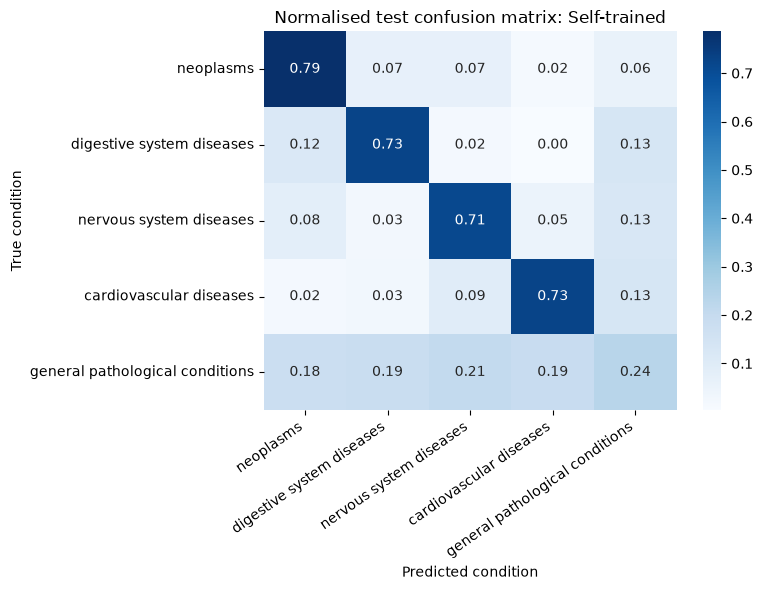

In [16]:
best_embedding_label = max(comparison_validation, key=lambda name: comparison_validation[name]["macro_f1"])
report = classification_report(
    comparison_test[best_embedding_label]["targets"],
    comparison_test[best_embedding_label]["predictions"],
    target_names=[index_to_name[index] for index in range(len(index_to_name))],
    output_dict=True,
    zero_division=0
)
display(pd.DataFrame(report).T.round(4))

matrix = confusion_matrix(
    comparison_test[best_embedding_label]["targets"],
    comparison_test[best_embedding_label]["predictions"],
    normalize="true"
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[index_to_name[index] for index in range(len(index_to_name))],
    yticklabels=[index_to_name[index] for index in range(len(index_to_name))]
)
plt.xlabel("预测类别")
plt.ylabel("真实类别")
plt.title(f"归一化测试集混淆矩阵：{best_embedding_label}")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 架构与词向量分析

BiLSTM-64 在架构筛选中取得最高的验证集 macro-F1（0.5632），高于 BiLSTM-96（0.5518）和 UniLSTM-64（0.5017）。这表明双向结构有助于同时利用序列两侧的证据，而更大的模型容量在当前验证划分上并未带来足够收益。因此，在比较词向量之前锁定 BiLSTM-64 配置。

在相同架构下，自训练词向量的验证集/测试集 macro-F1 分别为 0.5582/0.5760，scispaCy 则为 0.5413/0.5560；测试准确率分别为 0.5744 和 0.5623。该比较是严格配对的：两个模型使用相同的数据、200 维向量、词表、微调策略、优化器、类别权重、训练轮数上限和随机种子。

外在评估的排序与内在评估并不一致。scispaCy 在 UMNSRS 上更强，但 SG-w10 的分类效果更好。UMNSRS 衡量一般概念语义相似度，而分类标签需要语料特有的判别线索。自训练词向量直接从当前医学摘要中学习，并且按构造覆盖分类词表的 100%；scispaCy 分类词表中有 3.46% 的词元只能随机初始化。微调也可能进一步塑造对当前任务有用的局部语义邻域。另一方面，当部署文本与当前语料分布不同时，scispaCy 更广泛的语义覆盖仍可能有优势。

选定模型在肿瘤和心血管疾病类别上表现最好。范围宽泛且异质的“一般病理状况”类别召回率仅为 0.2354。类别权重提高了模型对较小类别的关注，但也促使模型减少对多数类别的预测。这说明 macro-F1 与逐类别报告比单独的准确率更具解释力。

## Task 5 - 融合生物医学 NER 信息

选定的 NER 系统是 AllenAI **scispaCy `en_ner_bc5cdr_md` 0.5.4**。该模型针对 BioCreative V Chemical Disease Relation（BC5CDR）语料训练，可以识别 `DISEASE` 和 `CHEMICAL` 实体跨度，与医学摘要中常见的诊断和治疗语言直接对应。

资料来源：

- [scispaCy 生物医学 NER 模型发布页面](https://allenai.github.io/scispacy/)
- [Li 等（2016），BioCreative V CDR 任务语料](https://academic.oup.com/database/article/doi/10.1093/database/baw068/2630414)

### 特征设计

从每篇摘要提取五个显式文档特征：对数缩放后的疾病数量、化学物质数量、不同疾病数量、不同化学物质数量，以及所有命名实体覆盖字符的比例。`StandardScaler` 仅在拟合分区上训练。随后将这些数值与 LSTM 的最终序列表示拼接，再输入全连接层。该方法计算开销较小，保留原始序列文本输入，并允许分类器学习实体密度与多样性是否具有类别判别能力。

In [17]:
ner_nlp = spacy.load(
    "en_ner_bc5cdr_md",
    disable=["tagger", "parser", "lemmatizer", "attribute_ruler"]
)
example_rows = []
for document_index, document in enumerate(ner_nlp.pipe(fit_df.medical_abstract.iloc[:3], batch_size=3), start=1):
    for entity in list(document.ents)[:10]:
        example_rows.append({"abstract": document_index, "entity": entity.text, "type": entity.label_})
display(pd.DataFrame(example_rows))

,abstract,entity,type
0,1,vitamins,CHEMICAL
1,1,beta-carotene,CHEMICAL
2,1,malignant transformation,DISEASE
3,1,"cancers of the lung, uterine cervix",DISEASE
4,1,gastrointestinal tract,DISEASE
5,1,cancer,DISEASE
6,1,vitamin C,CHEMICAL
7,1,dysplasia,DISEASE
8,1,vitamin C,CHEMICAL
9,1,beta-carotene,CHEMICAL


In [18]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
ner_cache = ARTIFACT_DIR / "ner_features.npz"

def entity_feature_matrix(texts):
    rows = []
    for text, document in zip(texts, ner_nlp.pipe(texts, batch_size=32)):
        diseases = [entity.text.lower() for entity in document.ents if entity.label_ == "DISEASE"]
        chemicals = [entity.text.lower() for entity in document.ents if entity.label_ == "CHEMICAL"]
        covered = sum(entity.end_char - entity.start_char for entity in document.ents)
        rows.append([
            np.log1p(len(diseases)),
            np.log1p(len(chemicals)),
            np.log1p(len(set(diseases))),
            np.log1p(len(set(chemicals))),
            covered / max(len(text), 1)
        ])
    return np.asarray(rows, dtype=np.float32)

expected_sizes = (len(fit_df), len(val_df), len(test_df))
if ner_cache.exists():
    cached = np.load(ner_cache)
    cached_sizes = tuple(len(cached[name]) for name in ["fit", "validation", "test"])
else:
    cached_sizes = ()
if cached_sizes == expected_sizes:
    fit_ner_raw = cached["fit"]
    val_ner_raw = cached["validation"]
    test_ner_raw = cached["test"]
else:
    fit_ner_raw = entity_feature_matrix(fit_df.medical_abstract.tolist())
    val_ner_raw = entity_feature_matrix(val_df.medical_abstract.tolist())
    test_ner_raw = entity_feature_matrix(test_df.medical_abstract.tolist())
    np.savez_compressed(ner_cache, fit=fit_ner_raw, validation=val_ner_raw, test=test_ner_raw)

ner_scaler = StandardScaler().fit(fit_ner_raw)
fit_ner = ner_scaler.transform(fit_ner_raw).astype(np.float32)
val_ner = ner_scaler.transform(val_ner_raw).astype(np.float32)
test_ner = ner_scaler.transform(test_ner_raw).astype(np.float32)
display(pd.DataFrame(fit_ner_raw, columns=["log_disease", "log_chemical", "log_unique_disease", "log_unique_chemical", "entity_char_fraction"]).describe().round(3))

,log_disease,log_chemical,log_unique_disease,log_unique_chemical,entity_char_fraction
count,9240.000,9240.000,9240.000,9240.000,9240.000
mean,1.951,0.734,1.607,0.540,0.122
std,0.672,0.934,0.580,0.674,0.078
min,0.000,0.000,0.000,0.000,0.000
25%,1.609,0.000,1.099,0.000,0.065
50%,2.079,0.000,1.609,0.000,0.110
75%,2.398,1.386,2.079,1.099,0.164
max,3.784,3.584,3.555,2.944,0.528


In [19]:
ner_model, ner_history, ner_validation = train_model(
    pretrained_matrix,
    selected_config,
    train_features=fit_ner,
    validation_features=val_ner,
    max_epochs=5,
    patience=2
)
ner_test_loader = DataLoader(
    AbstractDataset(test_sequences, y_test, test_ner),
    batch_size=128,
    shuffle=False,
    collate_fn=collate_batch
)
ner_test = evaluate_model(ner_model, ner_test_loader)
ner_comparison = pd.DataFrame([
    {
        "model": "Pretrained biomedical LSTM",
        "validation_accuracy": comparison_validation["Pretrained biomedical"]["accuracy"],
        "validation_macro_f1": comparison_validation["Pretrained biomedical"]["macro_f1"],
        "test_accuracy": comparison_test["Pretrained biomedical"]["accuracy"],
        "test_macro_f1": comparison_test["Pretrained biomedical"]["macro_f1"]
    },
    {
        "model": "Pretrained biomedical LSTM + NER",
        "validation_accuracy": ner_validation["accuracy"],
        "validation_macro_f1": ner_validation["macro_f1"],
        "test_accuracy": ner_test["accuracy"],
        "test_macro_f1": ner_test["macro_f1"]
    }
])
display(ner_comparison.round(4))

,model,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1
0,Pretrained biomedical LSTM,0.5502,0.5413,0.5623,0.5560
1,Pretrained biomedical LSTM + NER,0.5528,0.5473,0.5741,0.5699


### NER 对比与解释

加入五个 BC5CDR 实体特征后，验证集 macro-F1 从 0.5413 提升至 0.5473，测试集 macro-F1 从 0.5560 提升至 0.5699；测试准确率从 0.5623 提升至 0.5741。虽然作业并不要求 NER 必须带来改进，但方向一致的小幅提升表明，显式的疾病/化学物质密度与多样性能够在预训练词元序列之外提供额外信息。

提升幅度有限的原因包括：文档级计数丢失了实体身份、否定关系、实体间关系与位置；同时，BC5CDR 只识别疾病和化学物质，而部分目标类别主要依赖解剖或生理信息。未来可将 BIO 实体标签与词元对齐、学习实体类型嵌入，或编码规范化实体身份，但这些方法会增加稀疏性和计算量，并且应在独立验证集上评估。

## Task 6 - 可独立执行的 Google Colab 推理

### 模型选择与可移植模型包

可部署模型严格按照验证集 macro-F1，从自训练基线、预训练基线和“预训练 + NER”模型中选择。下面的导出代码将词表、标签映射、网络配置、可选 NER 标准化参数以及半精度模型权重保存为压缩的 Base64 数据包。将其直接嵌入 Notebook 既满足仅提交一个文件的要求，也避免推理依赖前面的训练单元格。

In [20]:
deployment_candidates = {
    "Self-trained": (comparison_models["Self-trained"], comparison_validation["Self-trained"], False),
    "Pretrained biomedical": (comparison_models["Pretrained biomedical"], comparison_validation["Pretrained biomedical"], False),
    "Pretrained biomedical + NER": (ner_model, ner_validation, True)
}
selected_deployment_name = max(deployment_candidates, key=lambda name: deployment_candidates[name][1]["macro_f1"])
selected_deployment_model, selected_deployment_validation, selected_uses_ner = deployment_candidates[selected_deployment_name]
portable_state = {
    key: value.detach().cpu().half() if value.is_floating_point() else value.detach().cpu()
    for key, value in selected_deployment_model.state_dict().items()
}
bundle = {
    "state_dict": portable_state,
    "token_to_idx": token_to_idx,
    "index_to_name": index_to_name,
    "max_len": MAX_LEN,
    "config": selected_config,
    "uses_ner": selected_uses_ner,
    "scaler_mean": ner_scaler.mean_.tolist() if selected_uses_ner else None,
    "scaler_scale": ner_scaler.scale_.tolist() if selected_uses_ner else None,
    "model_name": selected_deployment_name
}
buffer = io.BytesIO()
torch.save(bundle, buffer)
bundle_b64 = base64.b64encode(gzip.compress(buffer.getvalue(), compresslevel=9)).decode("ascii")
(ARTIFACT_DIR / "inference_bundle.txt").write_text(bundle_b64)
print("选定的部署模型：", selected_deployment_name)
print("验证集 macro-F1：", round(selected_deployment_validation["macro_f1"], 4))
print("内嵌模型包大小：", f"{len(bundle_b64) / 1_000_000:.2f} MB")

选定的部署模型： Self-trained
验证集 macro-F1： 0.5582
内嵌模型包大小： 7.94 MB


### 全新运行时表单

在新的 Google Colab 运行时中，只需运行下面两个单元格。第一个单元格包含全部模型资源与定义；第二个单元格是 Google Colab 表单。将默认英文摘要替换为待预测的英文医学摘要，然后运行该单元格。表单会严格复现训练阶段的分词与截断策略，在需要时提取并标准化 NER 特征，恢复 LSTM，并显示预测类别及各类别概率。

In [1]:
import base64
import gzip
import importlib.util
import io
import re
import subprocess
import sys

if importlib.util.find_spec("torch") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch"])

import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

BUNDLE_B64 = "..."
bundle = torch.load(io.BytesIO(gzip.decompress(base64.b64decode(BUNDLE_B64))), map_location="cpu", weights_only=False)

if bundle["uses_ner"]:
    if importlib.util.find_spec("spacy") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "spacy==3.7.5"])
    if importlib.util.find_spec("en_ner_bc5cdr_md") is None:
        source = "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz"
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", source])
    import spacy
    inference_ner = spacy.load("en_ner_bc5cdr_md", disable=["tagger", "parser", "lemmatizer", "attribute_ruler"])
else:
    inference_ner = None

class PortableLSTMClassifier(nn.Module):
    def __init__(self, vocabulary_size, embedding_dimension, hidden_size, bidirectional, dropout, feature_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocabulary_size, embedding_dimension, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dimension, hidden_size, batch_first=True, bidirectional=bidirectional)
        representation_size = hidden_size * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.hidden = nn.Linear(representation_size + feature_dim, hidden_size)
        self.output = nn.Linear(hidden_size, len(bundle["index_to_name"]))
        self.bidirectional = bidirectional

    def forward(self, tokens, lengths, features=None):
        embedded = self.embedding(tokens)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        representation = torch.cat((hidden[-2], hidden[-1]), dim=1) if self.bidirectional else hidden[-1]
        if features is not None and features.shape[1] > 0:
            representation = torch.cat((representation, features), dim=1)
        representation = self.dropout(torch.relu(self.hidden(representation)))
        return self.output(representation)

embedding_shape = bundle["state_dict"]["embedding.weight"].shape
feature_dim = 5 if bundle["uses_ner"] else 0
inference_model = PortableLSTMClassifier(
    embedding_shape[0],
    embedding_shape[1],
    bundle["config"]["hidden_size"],
    bundle["config"]["bidirectional"],
    bundle["config"]["dropout"],
    feature_dim
)
inference_model.load_state_dict(bundle["state_dict"])
inference_model.eval()
inference_pattern = re.compile(r"[a-z]+(?:[-'][a-z]+)?|\d+(?:\.\d+)?")

def prepare_inference(abstract):
    tokens = inference_pattern.findall(abstract.lower())
    maximum = bundle["max_len"]
    if len(tokens) > maximum:
        half = maximum // 2
        tokens = tokens[:half] + tokens[-half:]
    indices = [bundle["token_to_idx"].get(token, 1) for token in tokens] or [1]
    token_tensor = torch.tensor([indices], dtype=torch.long)
    length_tensor = torch.tensor([len(indices)], dtype=torch.long)
    if not bundle["uses_ner"]:
        return token_tensor, length_tensor, torch.zeros((1, 0), dtype=torch.float32)
    document = inference_ner(abstract)
    diseases = [entity.text.lower() for entity in document.ents if entity.label_ == "DISEASE"]
    chemicals = [entity.text.lower() for entity in document.ents if entity.label_ == "CHEMICAL"]
    covered = sum(entity.end_char - entity.start_char for entity in document.ents)
    raw = np.array([[
        np.log1p(len(diseases)),
        np.log1p(len(chemicals)),
        np.log1p(len(set(diseases))),
        np.log1p(len(set(chemicals))),
        covered / max(len(abstract), 1)
    ]], dtype=np.float32)
    scaled = (raw - np.asarray(bundle["scaler_mean"])) / np.asarray(bundle["scaler_scale"])
    return token_tensor, length_tensor, torch.tensor(scaled, dtype=torch.float32)

print("可移植模型已就绪：", bundle["model_name"])

可移植模型已就绪： Self-trained


In [2]:
#@title 生物医学摘要预测
abstract_text = "A patient with progressive chest pain and shortness of breath underwent coronary angiography, which showed severe stenosis of the left anterior descending artery." #@param {type:"string"}

tokens, lengths, features = prepare_inference(abstract_text)
with torch.no_grad():
    probabilities = torch.softmax(inference_model(tokens, lengths, features), dim=1)[0].numpy()
prediction_index = int(probabilities.argmax())
prediction_name = bundle["index_to_name"][prediction_index]
print("预测的医学类别：", prediction_name)
print("各类别概率：")
for index in np.argsort(probabilities)[::-1]:
    print(f"  {bundle['index_to_name'][int(index)]}: {probabilities[index]:.4f}")

预测的医学类别： cardiovascular diseases
各类别概率：
  cardiovascular diseases: 0.6680
  general pathological conditions: 0.2670
  nervous system diseases: 0.0601
  digestive system diseases: 0.0028
  neoplasms: 0.0021


## 结论

受控实验最终选择了包含 64 个隐藏单元的双向 LSTM，并使用自训练的 200 维 SG-w10 词向量。模型选择只依据验证集 macro-F1；在完全未参与调参的测试集上，其准确率为 0.5744，macro-F1 为 0.5760。预训练 scispaCy 向量在内在评估中更强，并覆盖更多 UMNSRS 概念对；但对于当前特定语料的分类任务，自训练词向量效果更好。显式 BC5CDR NER 特征改善了预训练基线，但其验证表现仍未超过自训练模型，因此可移植推理表单部署自训练系统。这一结果说明，内在语义相似度、下游判别能力和领域覆盖率应分别评估。

### 可复现性与局限性

数据划分和各随机库均设置固定种子，Word2Vec 使用单工作线程，所有比较均成对进行。不同 Colab 硬件上的 GPU 数值运算仍可能产生轻微差异。本研究仅覆盖一个数据集、一类序列架构、有限词表、一种截断策略和一个 NER 本体。UMNSRS 测量语义相似度而非标签判别能力，因此内在与下游评估的排序不必一致。最终测试结果不应再用于后续模型选择。